# Random Matrix Theory

You have a sample correlation matrix from $T$ observations of $N$ assets. You eigendecompose it and get $N$ eigenvalues. **Which of those eigenvalues represent real structure, and which are just noise from having finite data?**

**The key idea — the null model.** Suppose the assets were *completely uncorrelated* — pure noise, no real structure at all. The true correlation matrix would be the identity $I$, with every eigenvalue exactly 1. But if you *estimate* a correlation matrix from finite data ($T$ samples) on $N$ truly-independent series, you won't get all eigenvalues equal to 1 — sampling noise spreads them out into a whole distribution of values, some well above 1, some near 0.

RMT's gift: it tells you, *exactly*, what that distribution of noise eigenvalues looks like. So you have a **null hypothesis for what pure noise produces**. Any eigenvalue in your real data that falls *inside* the noise distribution is statistically indistinguishable from noise — it carries no reliable information. Any eigenvalue that pokes *outside* the noise band is real signal — it's too large to be a sampling artifact.

That's the whole conceptual engine: **RMT gives you the noise distribution, so you can separate signal eigenvalues (outside the band) from noise eigenvalues (inside it).** It's a statistical significance test for eigenvalues.

The critical parameter is the **aspect ratio $q = N/T$** — assets divided by observations. This is the same $N$-vs-$T$ quantity from the rank-deficiency and $n<p$ discussions, now controlling how wide the noise band is. When $q$ is small (lots of data per asset), noise is tightly concentrated near 1 and signal is easy to separate. When $q \to 1$, the noise band is enormous and most of your eigenvalues are indistinguishable from noise.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from util import util_yahoo_finance as uyf

In [2]:
tickers = ["NVDA", "AAPL", "MSFT", "MU", "AMZN", "AMD", "GOOGL", "TSLA", "GOOG", "AVGO"]
returns = uyf.get_returns(tickers, start="2024-01-01")
aspect_ratio = returns.shape[1] / returns.shape[0]
print(f"Aspect Ratio: {aspect_ratio:.4f}")

Aspect Ratio: 0.0164


## The Marchenko-Pastur Law

Here's the precise statement of "what pure noise produces." Take $N$ truly independent series (no real correlation), estimate the correlation matrix from $T$ observations, and look at the distribution of its eigenvalues as $N, T \to \infty$ with the ratio $q = N/T$ held fixed. The **Marchenko-Pastur law** says those eigenvalues follow a specific density, supported between two sharp edges:

$$
\lambda_{\pm} = \sigma^2\left(1 \pm \sqrt{q}\right)^2
$$

For a correlation matrix the variance $\sigma^2 = 1$, so:

$$
\lambda_- = (1 - \sqrt{q})^2, \qquad \lambda_+ = (1 + \sqrt{q})^2
$$

Every noise eigenvalue lands between $\lambda_-$ and $\lambda_+$. The density between them is:

$$
\rho(\lambda) = \frac{1}{2\pi q}\frac{\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)}}{\lambda}
$$

You don't need to memorize the density — the **edges $\lambda_\pm$ are the whole point**.

Edges are 0.7603 and 1.2725


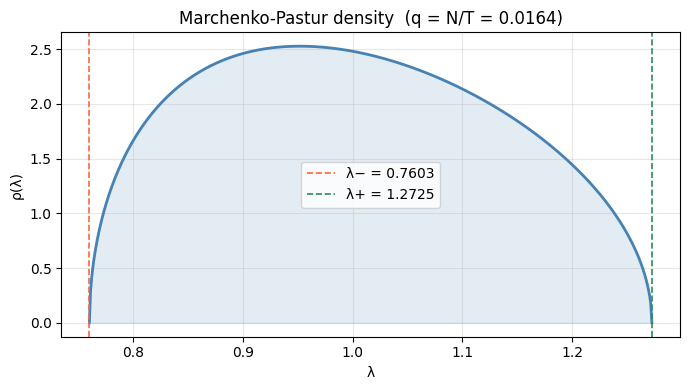

In [3]:
lambda_plus = (1 + np.sqrt(aspect_ratio)) ** 2
lambda_minus = (1 - np.sqrt(aspect_ratio)) ** 2
print(f"Edges are {lambda_minus:.4f} and {lambda_plus:.4f}")

lam = np.linspace(lambda_minus, lambda_plus, 500)
rho = (1 / (2 * np.pi * aspect_ratio)) * np.sqrt((lambda_plus - lam) * (lam - lambda_minus)) / lam

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lam, rho, color="steelblue", lw=2)
ax.fill_between(lam, rho, alpha=0.15, color="steelblue")
ax.axvline(lambda_minus, color="tomato", ls="--", lw=1.2, label=f"λ− = {lambda_minus:.4f}")
ax.axvline(lambda_plus,  color="seagreen", ls="--", lw=1.2, label=f"λ+ = {lambda_plus:.4f}")
ax.set_xlabel("λ")
ax.set_ylabel("ρ(λ)")
ax.set_title(f"Marchenko-Pastur density  (q = N/T = {aspect_ratio:.4f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the edges.** If your assets were pure noise, *all* $N$ eigenvalues would fall in $[\lambda_-, \lambda_+]$. So:

- **Eigenvalues inside $[\lambda_-, \lambda_+]$** — statistically indistinguishable from noise. No reliable information.
- **Eigenvalues above $\lambda_+$** — too large to be a sampling artifact. **Real signal.**

So any eigenvalue between 0.7601 and 1.2727 is noise-level. Only eigenvalues above 1.2727 are real. The less data per asset, the wider the noise band, the fewer eigenvalues you can trust.

In [4]:
cov = returns.cov().values * 252
cond_num = np.linalg.cond(cov)
print(f"Condition Number: {cond_num}")

std_devs = np.sqrt(np.diag(cov))
std_matrix = np.outer(std_devs, std_devs)
    
# Divide the covariance matrix by the standard deviation matrix
# Use np.divide and np.errstate to safely handle any zero-variance edge cases
with np.errstate(divide='ignore', invalid='ignore'):
    corr_matrix = np.divide(cov, std_matrix)
    
    # Force the diagonal to be exactly 1.0 (corrects for minor floating point errors)
    np.fill_diagonal(corr_matrix, 1.0)
    
    # If any variances were zero, the division yields NaN. Replace them with 0.
    corr_matrix = np.nan_to_num(corr_matrix)

Condition Number: 4818.664596815028


## Eigenvalue Cleaning

**The setup.** Eigendecompose the sample correlation matrix:

$$
\hat{C} = \sum_{i=1}^N \lambda_i\, v_i v_i^T
$$

eigenvalues $\lambda_i$, eigenvectors $v_i$. Sort them descending. Marchenko-Pastur gives you the cutoff $\lambda_+ = (1+\sqrt{q})^2$. Some eigenvalues sit above it (signal), the bulk sit inside $[\lambda_-, \lambda_+]$ (noise).

**The cleaning procedure (the standard one — "eigenvalue clipping"):**

1. **Keep the signal eigenvalues** above $\lambda_+$ unchanged — they're real (market, sectors, styles).
2. **Replace the noise eigenvalues** (those $\leq \lambda_+$) with a *single common value* — their average — so collectively they preserve the total variance but carry no spurious structure.
3. **Rebuild** the matrix from the original eigenvectors and the modified eigenvalues.

Formally, if eigenvalues $\lambda_1, \ldots, \lambda_k$ are above the cutoff (signal) and $\lambda_{k+1}, \ldots, \lambda_N$ are below (noise), replace each noise eigenvalue with their average $\bar\lambda = \frac{1}{N-k}\sum_{i>k}\lambda_i$:

$$
\hat{C}_{\text{clean}} = \sum_{i=1}^k \lambda_i\, v_i v_i^T + \bar\lambda\sum_{i=k+1}^N v_i v_i^T
$$

In [5]:
# Used eigh (not eig) since the correlation matrix is symmetric — it's faster, numerically more stable, and guarantees real eigenvalues. 
eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
eigenvalues = eigenvalues[::-1]       # sort descending
eigenvectors = eigenvectors[:, ::-1]

print(f"{'#':<4}  {'Eigenvalue':>12}  {'vs λ+':>8}  {'Signal?':>8}")
print("-" * 40)
for i, lam in enumerate(eigenvalues):
    signal = lam > lambda_plus
    marker = "YES  ↑" if signal else "noise"
    print(f"{i+1:<4}  {lam:>12.6f}  {lam - lambda_plus:>+8.4f}  {marker}")

#       Eigenvalue     vs λ+   Signal?
----------------------------------------
1         4.870007   +3.5975  YES  ↑
2         1.275653   +0.0032  YES  ↑
3         0.850639   -0.4218  noise
4         0.725930   -0.5465  noise
5         0.564176   -0.7083  noise
6         0.512943   -0.7595  noise
7         0.479075   -0.7934  noise
8         0.383221   -0.8892  noise
9         0.335944   -0.9365  noise
10        0.002412   -1.2701  noise


**Two essential constraints:**

- **Preserve the trace.** Replacing noise eigenvalues with their *average* (not zero, not one) keeps $\sum\lambda_i$ unchanged. For a correlation matrix the trace must equal $N$ (the diagonal is all 1s), so the total variance is conserved — you've redistributed the noise eigenvalues to a flat level, not discarded their mass. Setting them to zero would destroy variance and break the correlation structure.
- **Rescale the diagonal back to 1.** After rebuilding, the diagonal may drift slightly off 1; you renormalize so it's a valid correlation matrix again.

In [6]:
signal_mask = eigenvalues > lambda_plus
noise_mask  = ~signal_mask

lambda_cleaned = eigenvalues.copy()
lambda_cleaned[noise_mask] = eigenvalues[noise_mask].mean()

# rebuild: C_clean = V diag(lambda_cleaned) V^T
corr_clean = eigenvectors @ np.diag(lambda_cleaned) @ eigenvectors.T

# force exact symmetry and unit diagonal (correct for floating-point drift)
corr_clean = (corr_clean + corr_clean.T) / 2
np.fill_diagonal(corr_clean, 1.0)

print(f"Signal eigenvalues kept : {signal_mask.sum()}")
print(f"Noise eigenvalues pooled: {noise_mask.sum()}  →  avg = {eigenvalues[noise_mask].mean():.6f}")

# rescale cleaned correlation back to covariance space:  Σ_ij = C_ij * σ_i * σ_j
cov_clean = corr_clean * np.outer(std_devs, std_devs)

print(f"Condition number:  original = {np.linalg.cond(cov):.1f}"
      f"  →  cleaned = {np.linalg.cond(cov_clean):.1f}")
print(f"\nDiagonal (variances) unchanged: {np.allclose(np.diag(cov_clean), np.diag(cov))}")
print(f"\nCleaned covariance matrix:")
print(np.round(cov_clean, 4))

Signal eigenvalues kept : 2
Noise eigenvalues pooled: 8  →  avg = 0.481793
Condition number:  original = 4818.7  →  cleaned = 41.1

Diagonal (variances) unchanged: True

Cleaned covariance matrix:
[[0.2392 0.0481 0.0524 0.1662 0.0708 0.1493 0.0541 0.1227 0.0534 0.1446]
 [0.0481 0.0735 0.0236 0.054  0.036  0.0536 0.0392 0.0563 0.0387 0.0493]
 [0.0524 0.0236 0.0601 0.0606 0.0333 0.0574 0.0322 0.0542 0.0318 0.0541]
 [0.1662 0.054  0.0606 0.3947 0.0804 0.1778 0.0571 0.1416 0.0564 0.1732]
 [0.0708 0.036  0.0333 0.0804 0.0971 0.0783 0.0524 0.0792 0.0517 0.0728]
 [0.1493 0.0536 0.0574 0.1778 0.0783 0.3318 0.0622 0.1346 0.0614 0.1551]
 [0.0541 0.0392 0.0322 0.0571 0.0524 0.0622 0.0911 0.0776 0.0645 0.0547]
 [0.1227 0.0563 0.0542 0.1416 0.0792 0.1346 0.0776 0.3533 0.0766 0.1266]
 [0.0534 0.0387 0.0318 0.0564 0.0517 0.0614 0.0645 0.0766 0.0886 0.0541]
 [0.1446 0.0493 0.0541 0.1732 0.0728 0.1551 0.0547 0.1266 0.0541 0.2688]]


The noise eigenvalues, left alone, are exactly the small/dispersed ones that $\Sigma^{-1}$ amplifies into garbage bets. By flattening them to a common value, you stop the optimizer from loading on noise directions while preserving the genuine factor structure (the big eigenvalues). Compare to yesterday's shrinkage:

- **Shrinkage** pulls *all* eigenvalues toward the target's spectrum — blunt, affects everything, including the real signal eigenvalues (it shrinks them too).
- **RMT clipping** is *surgical* — it leaves the signal eigenvalues *exactly* untouched and flattens *only* the ones MP identifies as noise. It knows precisely where to cut.

That's the signal/noise tradeoff between the two methods: shrinkage is robust and assumption-light but slightly distorts the real factors; RMT is sharper and preserves the factors but depends on the MP null model being appropriate (which assumes the noise is genuinely i.i.d. Gaussian-like — a real assumption that can be violated by fat tails or autocorrelation).